### Model Training

In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    auc
)

# Classification Models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE

# Warnings
import warnings
warnings.filterwarnings('ignore')

Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv('credit_data.csv')

Show Top 5 Records 

In [3]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Remove Duplicates

In [4]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (150000, 12)


Handle Missing Values

- MonthlyIncome -> median
- NumberOfDependents -> 0

In [5]:
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0)

print(df.isnull().sum())

Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         150000 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

Preparing X and Y Variable

In [7]:
X = df.drop(columns=['Unnamed: 0','SeriousDlqin2yrs'],axis=1)

In [8]:
y = df['SeriousDlqin2yrs']

Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape, X_test.shape)

(120000, 10) (30000, 10)


Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Handle imbalanced data with SMOTE

In [11]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

Create an Evaluate Function to give all metrics after model Training

In [12]:
def evaluate_model(true, predicted):
    acc = accuracy_score(true, predicted)
    prec = precision_score(true, predicted)
    rec = recall_score(true, predicted)
    f1 = f1_score(true, predicted)
    roc = roc_auc_score(true, predicted)

    precision, recall, _ = precision_recall_curve(true, predicted)
    pr_auc = auc(recall, precision)

    return acc, prec, rec, f1, roc, pr_auc

Logistic Regression
Model performance for Training set
- accuracy_score: 0.7058
- precision_score: 0.7298
- recall_score: 0.6536
- f1_score: 0.6896
- ROC-AUC: 0.7058
- PR-AUC: 0.7783
----------------------------------
Model performance for Test set
- accuracy_score: 0.7540
- precision_score: 0.1599
- recall_score: 0.6518
- f1_score: 0.2568
- ROC-AUC: 0.7065
- PR-AUC: 0.4172
----------------------------------


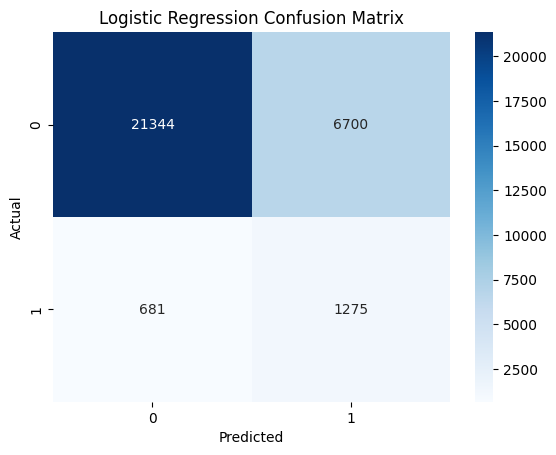



XGBClassifier
Model performance for Training set
- accuracy_score: 0.9420
- precision_score: 0.9688
- recall_score: 0.9134
- f1_score: 0.9403
- ROC-AUC: 0.9420
- PR-AUC: 0.9628
----------------------------------
Model performance for Test set
- accuracy_score: 0.9223
- precision_score: 0.3869
- recall_score: 0.3272
- f1_score: 0.3546
- ROC-AUC: 0.6455
- PR-AUC: 0.3790
----------------------------------


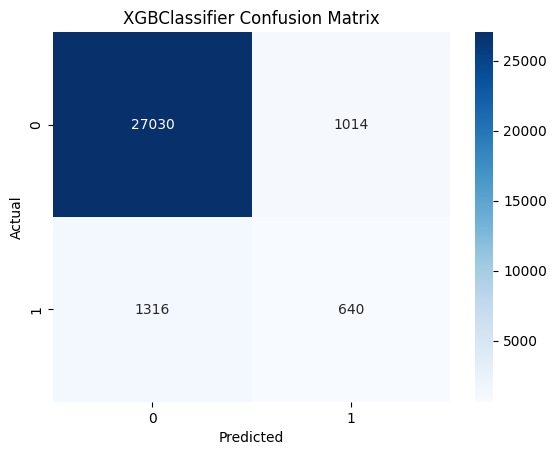

In [13]:
models = {
    "Logistic Regression": LogisticRegression(),
    "XGBClassifier": XGBClassifier()
}

model_list = []
roc_list = []

for i in range(len(list(models))):

    model = list(models.values())[i]

    # Train Model
    model.fit(X_train_smote, y_train_smote)

    # Predictions
    y_train_pred = model.predict(X_train_smote)
    y_test_pred = model.predict(X_test_scaled)

    # Evaluation
    model_train_acc, model_train_prec, model_train_rec, model_train_f1, model_train_roc, model_train_pr_auc = evaluate_model(
        y_train_smote,
        y_train_pred
    )

    model_test_acc, model_test_prec, model_test_rec, model_test_f1, model_test_roc, model_test_pr_auc = evaluate_model(
        y_test,
        y_test_pred
    )

    model_name = list(models.keys())[i]

    print(model_name)
    model_list.append(model_name)

    print("Model performance for Training set")
    print("- accuracy_score: {:.4f}".format(model_train_acc))
    print("- precision_score: {:.4f}".format(model_train_prec))
    print("- recall_score: {:.4f}".format(model_train_rec))
    print("- f1_score: {:.4f}".format(model_train_f1))
    print("- ROC-AUC: {:.4f}".format(model_train_roc))
    print("- PR-AUC: {:.4f}".format(model_train_pr_auc))

    print("----------------------------------")

    print("Model performance for Test set")
    print("- accuracy_score: {:.4f}".format(model_test_acc))
    print("- precision_score: {:.4f}".format(model_test_prec))
    print("- recall_score: {:.4f}".format(model_test_rec))
    print("- f1_score: {:.4f}".format(model_test_f1))
    print("- ROC-AUC: {:.4f}".format(model_test_roc))
    print("- PR-AUC: {:.4f}".format(model_test_pr_auc))

    roc_list.append(model_test_roc)

    print("----------------------------------")

    cm = confusion_matrix(y_test, y_test_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("=" * 35)
    print("\n")

Result

In [14]:
pd.DataFrame(list(zip(model_list, roc_list)), columns=['Model Name', 'roc_Score']).sort_values(by=["roc_Score"],ascending=False)

,Model Name,roc_Score
0,Logistic Regression,0.706465
1,XGBClassifier,0.645520


AdaBoost Classifier

In [16]:
xgb_model = XGBClassifier()
xgb_model.fit(X_train_smote, y_train_smote)

y_pred = xgb_model.predict(X_test_scaled)

score = accuracy_score(y_test, y_pred) * 100

print("Accuracy of the model is %.2f" % score)

Accuracy of the model is 92.23
